In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os


Image saved to: E:\LLM+XWT\实验结果\radar_chart_styled_v3.png


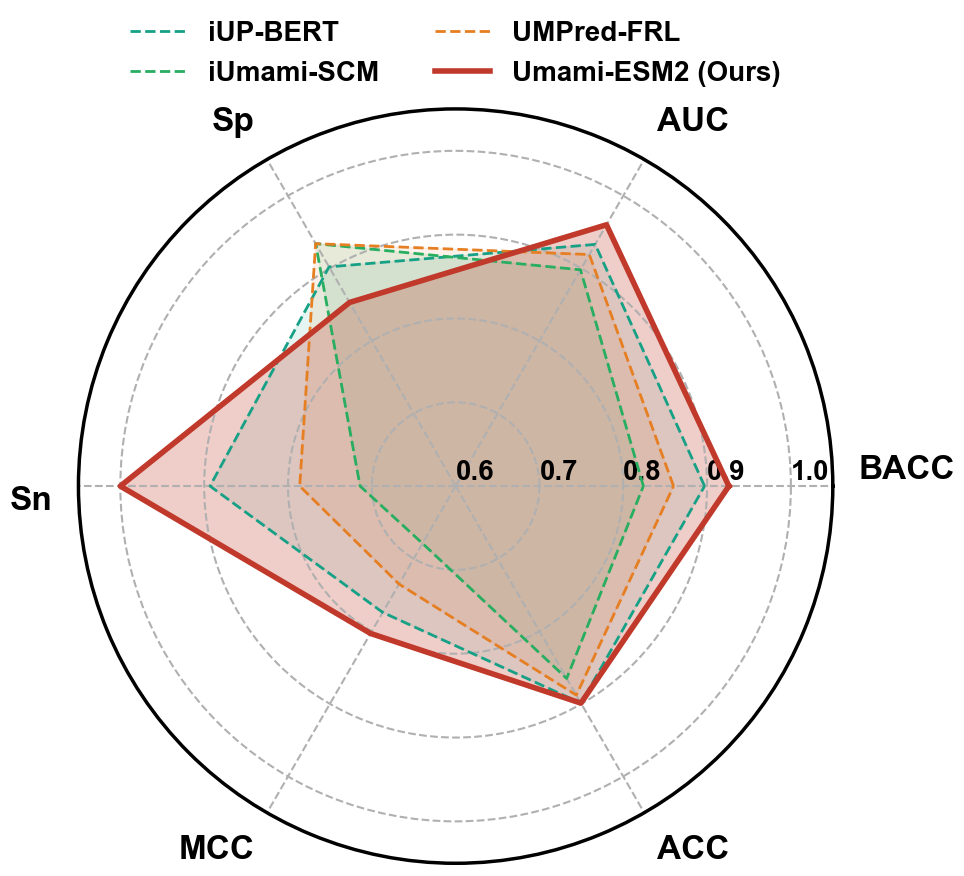

In [12]:

# --- 1. 全局样式设置 ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 20

# --- 保存目录 ---
output_directory = r'E:\LLM+XWT\实验结果'
os.makedirs(output_directory, exist_ok=True)

# --- 2. 数据准备 ---
labels = np.array(['BACC', 'AUC', 'Sp', 'Sn', 'MCC', 'ACC'])
num_vars = len(labels)

# 数据
iUP_BERT_stats = [0.897, 0.933, 0.902, 0.893, 0.774, 0.899]
iUP_BERT_stats += iUP_BERT_stats[:1]

iUmami_SCM_stats = [0.824, 0.898, 0.934, 0.714, 0.679, 0.865]
iUmami_SCM_stats += iUmami_SCM_stats[:1]

UMPred_FRL_stats = [0.860, 0.919, 0.934, 0.786, 0.735, 0.888]
UMPred_FRL_stats += UMPred_FRL_stats[:1]

UmamiESM2_stats = [0.926, 0.960, 0.853, 1.0, 0.803, 0.899]
UmamiESM2_stats += UmamiESM2_stats[:1]

# 角度
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# --- 3. 绘图设置 ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 设置Y轴范围
ax.set_ylim(0.6, 1.05) 

# 颜色定义
colors = {
    'iUP-BERT': '#16A085',
    'iUmami-SCM': '#27AE60',
    'UMPred-FRL': '#E67E22',
    'Umami-ESM2 (Ours)': '#C0392B'
}

# --- 4. 绘制数据 ---
ax.plot(angles, iUP_BERT_stats, color=colors['iUP-BERT'], linestyle='dashed', linewidth=2, label='iUP-BERT')
ax.fill(angles, iUP_BERT_stats, color=colors['iUP-BERT'], alpha=0.1)

ax.plot(angles, iUmami_SCM_stats, color=colors['iUmami-SCM'], linestyle='dashed', linewidth=2, label='iUmami-SCM')
ax.fill(angles, iUmami_SCM_stats, color=colors['iUmami-SCM'], alpha=0.1)

ax.plot(angles, UMPred_FRL_stats, color=colors['UMPred-FRL'], linestyle='dashed', linewidth=2, label='UMPred-FRL')
ax.fill(angles, UMPred_FRL_stats, color=colors['UMPred-FRL'], alpha=0.1)

ax.plot(angles, UmamiESM2_stats, color=colors['Umami-ESM2 (Ours)'], linewidth=4, label='Umami-ESM2 (Ours)')
ax.fill(angles, UmamiESM2_stats, color=colors['Umami-ESM2 (Ours)'], alpha=0.25)

# --- 5. 坐标轴与标签智能对齐 (核心修改) ---

# (1) 生成标签并设置基础距离
# pad=30 保证基础距离
ax.tick_params(axis='x', pad=8)

# (2) 获取标签对象
lines, text_labels = ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=24, fontweight='bold')

# (3) 【关键算法】遍历每个标签，根据角度动态调整对齐方式
for label, angle in zip(text_labels, angles[:-1]):
    # 将弧度转换为角度 (0-360)
    angle_deg = np.degrees(angle)
    
    # 水平对齐 (HA) 逻辑
    if angle_deg < 90 or angle_deg > 270:
        label.set_horizontalalignment('left')  # 右侧标签左对齐
    elif angle_deg > 90 and angle_deg < 270:
        label.set_horizontalalignment('right') # 左侧标签右对齐
    else:
        label.set_horizontalalignment('center') # 正上正下居中

    # 垂直对齐 (VA) 逻辑 (微调上下位置)
    if angle_deg < 180:
        label.set_verticalalignment('bottom')  # 上半圆标签底对齐
    else:
        label.set_verticalalignment('top')     # 下半圆标签顶对齐

# (4) 设置内部数值标签 (0.6, 0.7...) 并加粗
plt.yticks([0.6, 0.7, 0.8, 0.9, 1.0], 
           ["0.6", "0.7", "0.8", "0.9", "1.0"], 
           fontsize=20, fontweight='bold', color="black")

# (5) 调整数值标签的角度位置
ax.set_rlabel_position(0) 

# (6) 加粗外框圆和网格线
ax.spines['polar'].set_linewidth(2.5)
ax.grid(True, linewidth=1.5, linestyle='--')

# --- 6. 图例设置 ---
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), 
                   ncol=2, frameon=False, fontsize=20)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.tight_layout()

# --- 7. 保存与显示 ---
file_name = 'radar_chart_styled_v3.png'
save_path = os.path.join(output_directory, file_name)
plt.savefig(save_path, dpi=600, bbox_inches='tight')

print(f"Image saved to: {save_path}")
plt.show()